# 17.4 Convolutional Autoencoders

In [1]:
import tensorflow as tf

physical_devices = tf.config.list_physical_devices("GPU")
tf.config.experimental.set_memory_growth(physical_devices[0], True)
physical_devices

2023-07-24 09:55:54.096815: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-07-24 09:55:56.241343: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-07-24 09:55:56.277584: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-07-24 09:55:56.277864: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so retur

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [2]:
import matplotlib.pyplot as plt
from typing import Optional, Sequence

%matplotlib inline


def plot_images(
    images_norm: Sequence[Sequence[Sequence[float]]],
    labels: Sequence[int],
    label_text: str = "Label",
    n_cols: int = 10,
    sup_title: Optional[str] = None,
) -> None:
    n_images = len(images_norm)
    n_rows = round(np.ceil(n_images / n_cols))
    fig, axs = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        squeeze=False,
        figsize=(20, n_rows * 2 + 1),
        constrained_layout=True,
    )
    for ax, img, label in zip(axs.ravel(), images_norm, labels):
        ax.imshow(img, cmap="gray")
        ax.axis("off")
        ax.set_title(f"{label_text}: {label}", fontsize="large", fontweight="bold")
    if sup_title is not None:
        fig.suptitle(sup_title, fontsize="x-large", fontweight="bold")

##### Data

In [3]:
import tensorflow as tf
from sklearn.model_selection import train_test_split

(x_train_valid, y_train_valid), (x_test, y_test) = (
    tf.keras.datasets.fashion_mnist.load_data()
)
x_train, x_valid, y_train, y_valid = train_test_split(
    x_train_valid, y_train_valid, test_size=0.2, random_state=42
)

print("x_train:", x_train.shape)
print("x_valid:", x_valid.shape)
print("x_test:", x_test.shape)

x_train: (48000, 28, 28)
x_valid: (12000, 28, 28)
x_test: (10000, 28, 28)


In [4]:
import numpy as np

classes = np.array(
    [
        "T-shirt/top",
        "Trouser",
        "Pullover",
        "Dress",
        "Coat",
        "Sandal",
        "Shirt",
        "Sneaker",
        "Bag",
        "Ankle boot",
    ]
)

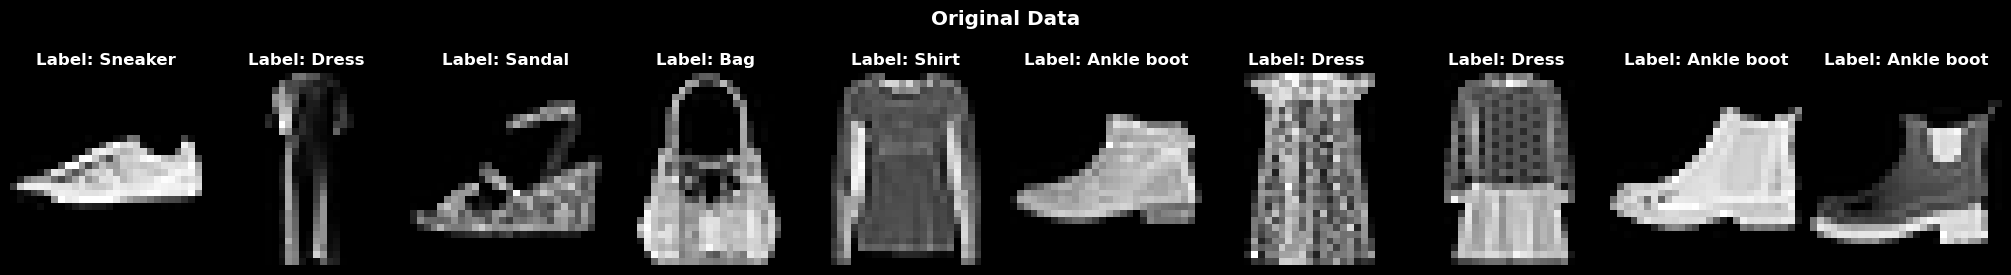

In [5]:
n_instances = 10
plot_images(
    images_norm=x_train[:n_instances],
    labels=classes[y_train[:n_instances]],
    sup_title="Original Data",
)

In [6]:
x_train_norm = x_train / 255.0
x_valid_norm = x_valid / 255.0
x_test_norm = x_test / 255.0

##### Model

In [7]:
import tensorflow as tf

encoder = tf.keras.models.Sequential(
    [
        tf.keras.layers.Reshape(target_shape=(28, 28, 1), input_shape=(28, 28)),
        tf.keras.layers.Conv2D(
            filters=16,
            kernel_size=3,
            padding="same",
            activation="selu",
            kernel_initializer="lecun_normal",
        ),
        tf.keras.layers.MaxPool2D(pool_size=2),
        tf.keras.layers.Conv2D(
            filters=32,
            kernel_size=3,
            padding="same",
            activation="selu",
            kernel_initializer="lecun_normal",
        ),
        tf.keras.layers.MaxPool2D(pool_size=2),
        tf.keras.layers.Conv2D(
            filters=64,
            kernel_size=3,
            padding="same",
            activation="selu",
            kernel_initializer="lecun_normal",
        ),
        tf.keras.layers.MaxPool2D(pool_size=2),
    ]
)
decoder = tf.keras.models.Sequential(
    [
        tf.keras.layers.Conv2DTranspose(
            filters=32,
            kernel_size=3,
            strides=2,
            padding="valid",
            activation="selu",
            kernel_initializer="lecun_normal",
            input_shape=(3, 3, 64),
        ),
        tf.keras.layers.Conv2DTranspose(
            filters=16,
            kernel_size=3,
            strides=2,
            padding="same",
            activation="selu",
            kernel_initializer="lecun_normal",
        ),
        tf.keras.layers.Conv2DTranspose(
            filters=1, kernel_size=3, strides=2, padding="same", activation="sigmoid"
        ),
        tf.keras.layers.Reshape(target_shape=(28, 28)),
    ]
)
conv_ae = tf.keras.models.Sequential([encoder, decoder])
conv_ae.compile(optimizer="adam", loss="binary_crossentropy")
conv_ae.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   


2023-07-24 09:55:58.627087: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-07-24 09:55:58.627849: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-07-24 09:55:58.628177: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-07-24 09:55:58.628396: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so retur

 sequential (Sequential)     (None, 3, 3, 64)          23296     
                                                                 
 sequential_1 (Sequential)   (None, 28, 28)            23233     
                                                                 
Total params: 46,529
Trainable params: 46,529
Non-trainable params: 0
_________________________________________________________________


In [8]:
cb_early_stopping = tf.keras.callbacks.EarlyStopping(
    patience=5, restore_best_weights=True
)
history = conv_ae.fit(
    x_train_norm,
    x_train_norm,
    batch_size=32,
    epochs=20,
    validation_data=[x_valid_norm, x_valid_norm],
    callbacks=[cb_early_stopping],
)

Epoch 1/20


2023-07-24 09:56:01.630094: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8401
2023-07-24 09:56:02.274468: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2023-07-24 09:56:02.275498: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2023-07-24 09:56:02.275540: W tensorflow/stream_executor/gpu/asm_compiler.cc:80] Couldn't get ptxas version string: INTERNAL: Couldn't invoke ptxas --version
2023-07-24 09:56:02.276609: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2023-07-24 09:56:02.276690: W tensorflow/stream_executor/gpu/redzone_allocator.cc:314] INTERNAL: Failed to launch ptxas
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.


1500/1500 [==============================] - 12s 6ms/step - loss: 0.2907 - val_loss: 0.2732
Epoch 2/20
1500/1500 [==============================] - 9s 6ms/step - loss: 0.2688 - val_loss: 0.2664
Epoch 3/20
1500/1500 [==============================] - 7s 5ms/step - loss: 0.2645 - val_loss: 0.2636
Epoch 4/20
1500/1500 [==============================] - 8s 5ms/step - loss: 0.2622 - val_loss: 0.2613
Epoch 5/20
1500/1500 [==============================] - 8s 5ms/step - loss: 0.2607 - val_loss: 0.2606
Epoch 6/20
1500/1500 [==============================] - 8s 5ms/step - loss: 0.2597 - val_loss: 0.2596
Epoch 7/20
1500/1500 [==============================] - 7s 5ms/step - loss: 0.2589 - val_loss: 0.2588
Epoch 8/20
1500/1500 [==============================] - 7s 5ms/step - loss: 0.2582 - val_loss: 0.2582
Epoch 9/20
1500/1500 [==============================] - 9s 6ms/step - loss: 0.2576 - val_loss: 0.2576
Epoch 10/20
1500/1500 [==============================] - 9s 6ms/step - loss: 0.2572 - val_lo

##### Evaluation

313/313 [==============================] - 3s 7ms/step


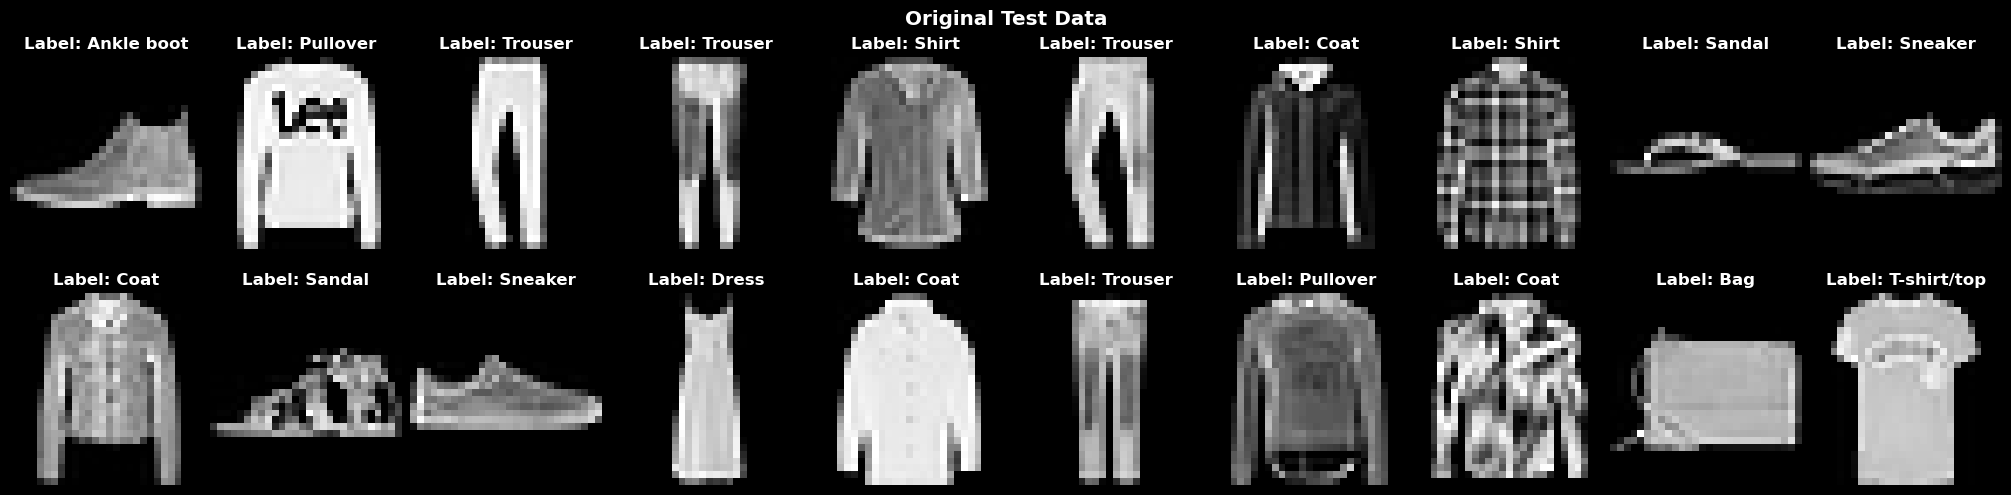

In [9]:
x_test_rec = conv_ae.predict(x_test_norm)

n_instances_test = 20
plot_images(
    images_norm=x_test[:n_instances_test],
    labels=classes[y_test[:n_instances_test]],
    sup_title="Original Test Data",
)

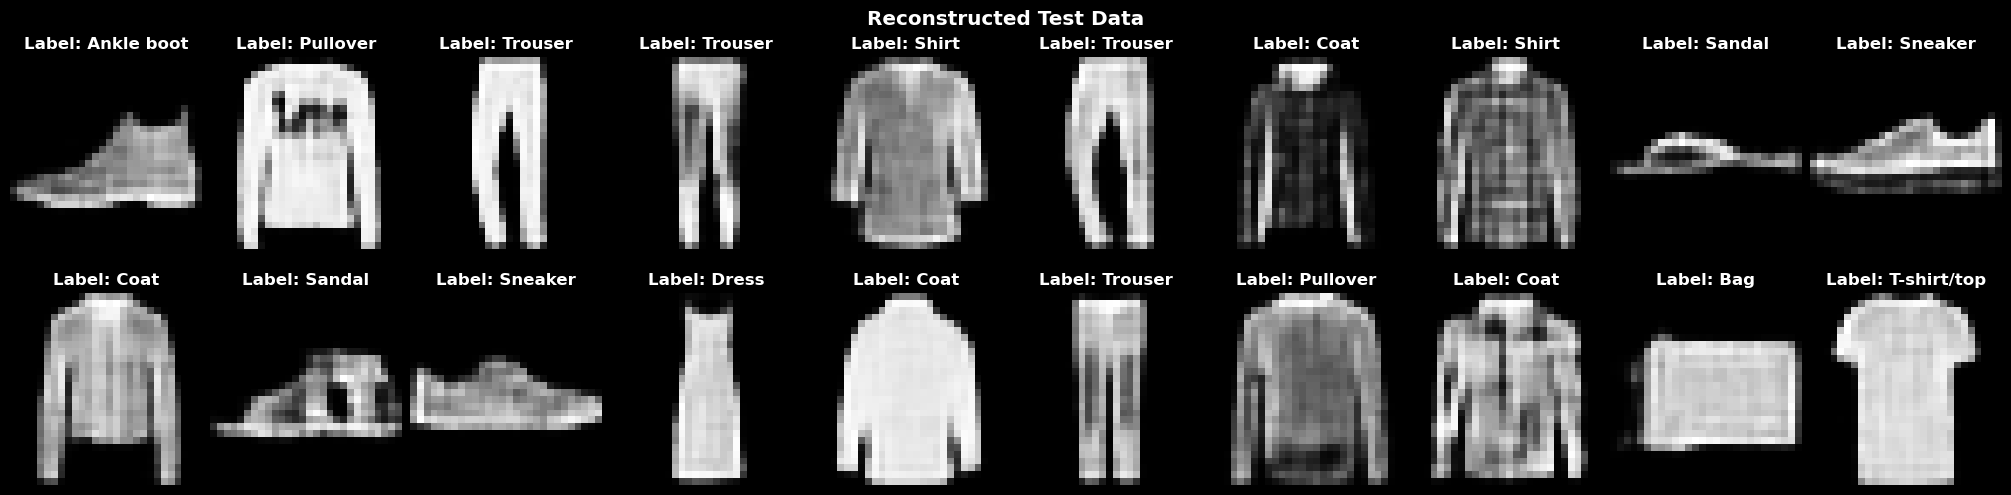

In [10]:
plot_images(
    images_norm=x_test_rec[:n_instances_test] * 255,
    labels=classes[y_test[:n_instances_test]],
    sup_title="Reconstructed Test Data",
)

##### Visualization

In [20]:
from sklearn.manifold import TSNE
from umap import UMAP

x_test_embedding = encoder.predict(x_test_norm)
x_test_embedding_flatten = x_test_embedding.reshape(-1, 3 * 3 * 64)

tsne = TSNE()
umap = UMAP()
x_test_2d_tsne = tsne.fit_transform(x_test_embedding_flatten)
x_test_2d_umap = umap.fit_transform(x_test_embedding_flatten)

313/313 [==============================] - 0s 1ms/step


(-95.27623023986817, 91.81307258605958, -81.95836944580078, 92.06865997314453)

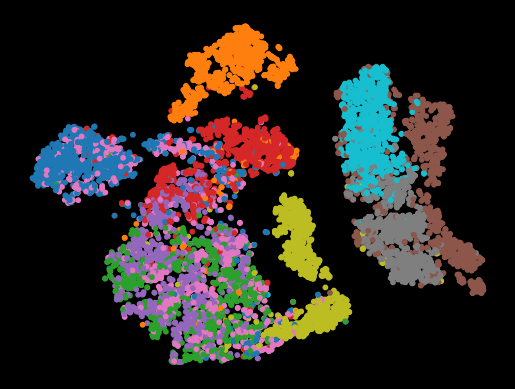

In [21]:
# t-SNE
fig, ax = plt.subplots()
ax.scatter(x_test_2d_tsne[:, 0], x_test_2d_tsne[:, 1], c=y_test, s=10, cmap="tab10")
ax.axis("off")

(-7.542231774330139,
 18.415775990486146,
 -6.305233955383301,
 14.475150108337402)

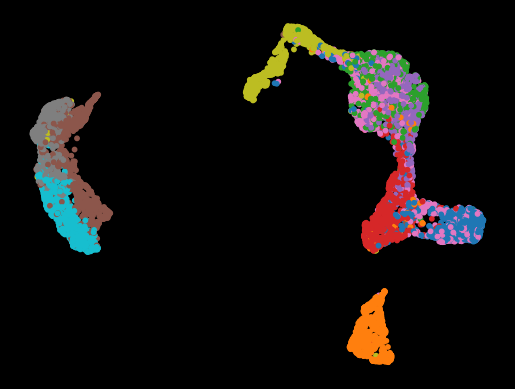

In [22]:
# UMAP
fig, ax = plt.subplots()
ax.scatter(x_test_2d_umap[:, 0], x_test_2d_umap[:, 1], c=y_test, s=10, cmap="tab10")
ax.axis("off")